# ENMO intégré par époque (10 s, 30 s, 60 s)

- **Dépôt GitHub :** https://github.com/SaidRodriguez22/Physical-activity-00.git

## 1. Objectif et méthode

On veut résumer un signal d'accélérométrie brut (50 Hz, poignet non dominant) par une mesure d'intensité d'activité par époque.

**ENMO** = *Euclidean Norm Minus One* : `sqrt(x² + y² + z²) − 1`, en g.
- La norme euclidienne combine les 3 axes, donc l'indicateur ne dépend pas de l'orientation du capteur.
- Au repos, la norme vaut ≈ 1 g (gravité seule) : on retranche 1 g pour retirer la gravité.
- On **garde les valeurs négatives** (norme légèrement < 1 g au repos, bruit et calibration) : les tronquer à 0 introduirait un biais positif. C'est pourquoi le signal au repos est légèrement négatif sur les graphiques.

**Intégration par époque** : on somme l'ENMO de tous les échantillons de l'époque et on multiplie par la durée de l'époque en minutes, ce qui donne une valeur en « g·min » comparable aux figures de l'énoncé.

# Etape1: Chargement du fichier
## Choix de la méthode de chargement (suggestions de Copilot)

Prompt démandé à copilot: Charge le fichier 0_z.csv avec pandas, sachant que la première ligne est un commentaire commençant par # .

Le fichier `0_z.csv` commence par une ligne de commentaire (`# accelerometer data in g`), suivie de l'en-tête `t,x,y,z`. Pandas doit donc ignorer cette première ligne, sinon il prendrait le commentaire pour l'en-tête. Copilot a proposé trois options.

**Option 1 : `pd.read_csv('0_z.csv', skiprows=1)`**
- `skiprows=1` saute la première ligne du fichier, quel que soit son contenu.
- Avantage : simple et explicite.
- Limite : elle suppose qu'il y a exactement une ligne à ignorer. Si un fichier avait deux lignes de commentaire, ou aucune, le chargement serait faux (perte de l'en-tête, ou commentaire lu comme données).

**Option 2 : `pd.read_csv('0_z.csv', comment='#')`**
- `comment='#'` ignore tout ce qui suit le caractère `#` sur une ligne. Une ligne qui commence par `#` est donc complètement ignorée.
- Avantage : ne dépend pas du nombre de lignes de commentaire, donc plus robuste si les fichiers varient.
- Limite : si un `#` apparaissait au milieu d'une ligne de données, la fin de la ligne serait ignorée (ce n'est pas le cas ici).

**Option 3 : `pd.read_csv('0_z.csv', skiprows=1, comment='#')`**
- Combine les deux : saute la première ligne, puis ignore d'éventuelles autres lignes de commentaire.
- Limite : redondante ici, car la première ligne est déjà un commentaire que `comment='#'` suffirait à ignorer. Elle cumule aussi les limites de l'option 1.

**Remarque sur le code proposé** : les trois lignes sont exécutées à la suite et réaffectent chacune la variable `df`. Seule la dernière compte, il faut donc n'en garder qu'une.

**Choix retenu : option 2.** Elle exprime directement l'intention (« ignorer les lignes de commentaire ») et reste valable si le nombre de lignes de commentaire change.


In [2]:
import pandas as pd

# choix de l'Option 2 :
df = pd.read_csv('0_z.csv', comment='#')

## Calcul de l'ENMO (suggestions de Copilot et choix retenu)

promt démandé à copilot: Écris une fonction qui calcule l’ENMO à partir des colonnes x, y, z.

L'ENMO (*Euclidean Norm Minus One*) se calcule pour chaque échantillon : `sqrt(x² + y² + z²) − 1`, en g. On prend la norme des trois axes, ce qui rend la mesure indépendante de l'orientation du capteur, puis on retire 1 g, la gravité mesurée au repos.

Copilot a proposé trois façons de l'appliquer.

**Option 1 : `calculate_enmo(x, y, z)` appelée sur les colonnes**
- La fonction prend `x`, `y`, `z` et renvoie l'ENMO. Appelée avec `df['x'], df['y'], df['z']`, elle calcule toutes les lignes d'un coup, grâce à la vectorisation de numpy.
- Avantage : rapide, lisible, et réutilisable sur un simple nombre ou sur un tableau.

**Option 2 : `df.apply(lambda row: ..., axis=1)`**
- Appelle la fonction ligne par ligne.
- Inconvénient : beaucoup plus lente (ici 21 000 lignes) pour un résultat identique, car l'option 1 fait déjà le calcul sur toute la colonne.

**Option 3 : `calculate_enmo_vectorized(df)`**
- Même calcul vectorisé, mais la fonction prend directement le DataFrame et dépend donc des noms de colonnes `x`, `y`, `z`.
- Avantage : appel court. Inconvénient : moins générale que l'option 1, qui fonctionne avec n'importe quelles données.

**Corrections apportées au code de Copilot**
- **Suppression de `np.abs`** : Copilot renvoyait la valeur absolue « pour éviter les valeurs négatives ». Or les valeurs négatives ont un sens : au repos, la norme est parfois légèrement inférieure à 1 g (bruit, calibration). Les rendre positives, ou les tronquer à 0, biaiserait l'intégration par époque. On les conserve.
- **Chargement** : `skiprows=1` remplacé par `comment='#'` (voir le choix précédent).
- **Doublons** : les fonctions et l'application de l'ENMO étaient écrites plusieurs fois. Une seule version est conservée.

**Choix retenu : option 1**, avec un appel vectorisé sur les colonnes. Elle est rapide, réutilisable, et ne dépend pas de la structure du DataFrame.

In [4]:
import numpy as np

In [5]:
def calculate_enmo(x, y, z):
    """ENMO = norme euclidienne (x, y, z) - 1, en g. Valeurs négatives conservées."""
    return np.sqrt(x**2 + y**2 + z**2) - 1

df['enmo'] = calculate_enmo(df['x'], df['y'], df['z'])

## Intégration de l'ENMO par époque (suggestion de Copilot et corrections)

Prompt demandé à copilot: Écris une fonction qui intègre l’ENMO par époque de N secondes et renvoie le résultat en g.min.

Pour chaque époque de N secondes, on regroupe les échantillons consécutifs (N × fréquence d'échantillonnage échantillons par époque) et on somme leur ENMO.

**Ce que fait le code de Copilot**
- Il vérifie les paramètres (durée et fréquence strictement positives, colonne présente).
- Il découpe la colonne ENMO en blocs de `N × fréquence` échantillons avec `reshape`, ce qui est rapide et lisible, puis somme chaque bloc.
- Il ignore la dernière époque si elle est incomplète, pour ne pas comparer des époques de durées différentes.
- Il renvoie un DataFrame avec le numéro de l'époque et la valeur intégrée.

**Problème repéré : l'échelle**
Copilot divise la somme par la fréquence puis par 60, ce qui donne l'intégrale exacte de l'ENMO dans le temps. Mais les figures de l'énoncé (par exemple un pic d'environ 122 g.min pour des époques de 10 s) correspondent à la somme de l'ENMO multipliée par la durée de l'époque en minutes. J'ai testé les deux calculs : avec la formule de Copilot, le pic vaut 0,245, loin des figures attendues. On adopte donc la formule qui reproduit l'énoncé.

**Corrections apportées**
- Valeur intégrée = somme des ENMO de l'époque × (N / 60).
- Ajout de la colonne `debut_min` (début de l'époque en minutes) pour tracer les barres sur l'axe du temps.
- Le nom de la colonne ENMO passé en paramètre est `enmo`, comme dans le reste du notebook.
- Les valeurs négatives de l'ENMO sont conservées (pas de valeur absolue).

**Limite** : la fonction suppose une fréquence d'échantillonnage constante (50 Hz ici) et des données sans trou. C'est le cas du fichier fourni (21 000 échantillons pour 420 s).


In [7]:
def enmo_par_epoque(df, n_secondes, frequence_hz, enmo_colonne="enmo"):
    """Intègre l'ENMO par époque (g.min) : somme des ENMO x durée de l'époque en minutes."""
    if n_secondes <= 0:
        raise ValueError("n_secondes doit être strictement positif.")
    if frequence_hz <= 0:
        raise ValueError("frequence_hz doit être strictement positive.")
    if enmo_colonne not in df.columns:
        raise ValueError(f"La colonne {enmo_colonne!r} est absente du DataFrame.")

    donnees = df[enmo_colonne].astype(float).to_numpy()

    echantillons_par_epoque = int(round(n_secondes * frequence_hz))
    if echantillons_par_epoque <= 0:
        raise ValueError("L'époque doit contenir au moins un échantillon.")

    nombre_epoques = len(donnees) // echantillons_par_epoque
    donnees = donnees[:nombre_epoques * echantillons_par_epoque]

    sommes = donnees.reshape(nombre_epoques, echantillons_par_epoque).sum(axis=1)
    resultat = sommes * (n_secondes / 60)

    return pd.DataFrame({
        "epoque": np.arange(nombre_epoques),
        "debut_min": np.arange(nombre_epoques) * n_secondes / 60,
        "ENMO_g_min": resultat,
    })


# Ces lignes sont HORS de la fonction (aucun espace au début)
fs = 1 / df['t'].diff().median()   # ≈ 50 Hz

resultat = enmo_par_epoque(df, n_secondes=60, frequence_hz=fs)
print(resultat)

   epoque  debut_min  ENMO_g_min
0       0        0.0 -135.986535
1       1        1.0 -135.529833
2       2        2.0 -134.928962
3       3        3.0 -135.749533
4       4        4.0  976.726915
5       5        5.0  -41.084322
6       6        6.0  -41.773346


## Tracé des deux panneaux (suggestion de Copilot et corrections)

Prompt demandé à copilot: Trace deux panneaux : les barres de l’ENMO intégré par époque, et l’ENMO brut en fonction du temps en minutes.

La figure demandée comporte deux panneaux : en haut, les barres de l'ENMO intégré par époque, en bas, l'ENMO brut en fonction du temps en minutes.

**Ce que fait le code de Copilot**
- Crée une figure à deux panneaux avec `plt.subplots(2, 1)`.
- Panneau du haut : `ax1.bar` avec les valeurs intégrées par époque.
- Panneau du bas : `ax2.plot` avec l'ENMO brut, l'axe des temps étant calculé à partir de l'indice de ligne et de la fréquence.
- Ajoute des lignes verticales en pointillés aux limites des époques, une légende, une grille et des couleurs personnalisées.

**Problèmes repérés et corrections**
- **Axe des x des barres** : Copilot place les barres selon le numéro d'époque (0, 1, 2…), alors que le panneau du bas est en minutes. Les deux panneaux ne sont donc pas alignés. On place les barres à `debut_min` avec une largeur `n_secondes / 60`, et on partage l'axe des x (`sharex=True`).
- **Fréquence** : l'appel utilisait `frequence_hz=100`, alors que le fichier est à 50 Hz. Le temps est maintenant lu directement dans la colonne `t` du fichier, ce qui supprime le besoin de la fréquence pour le tracé.
- **Nom de colonne** : `"ENMO"` remplacé par la colonne `enmo` du notebook.
- **Style** : suppression des pointillés, de la légende et des couleurs vives pour se rapprocher des figures de l'énoncé (barres grises, courbe bleue fine et semi-transparente, mêmes titres et libellés).
- **Sauvegarde** : `fig.savefig(...)` en fin de code Copilot provoquerait une erreur, car `fig` n'existe que dans la fonction. La fonction renvoie maintenant la figure.
- **Appels en double** supprimés.

**Choix retenu** : la version corrigée, appelée une fois pour chaque durée d'époque (10 s, 30 s, 60 s).

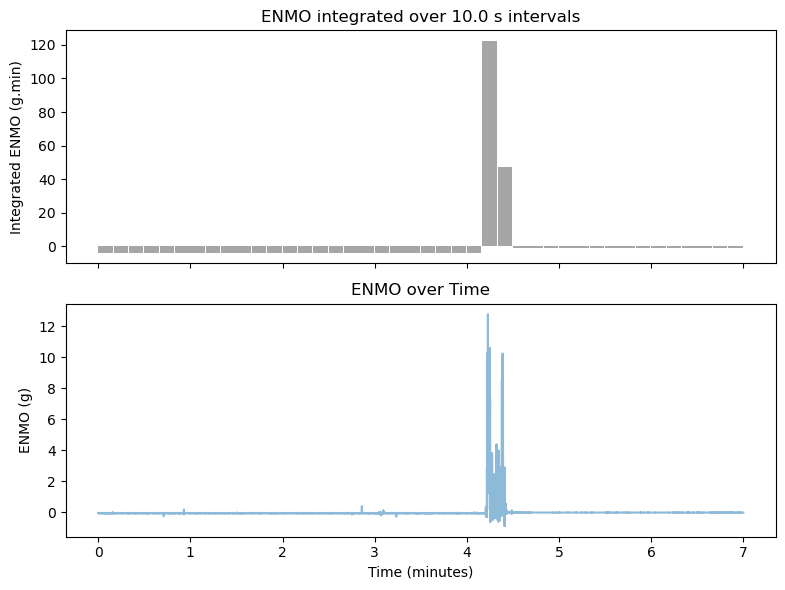

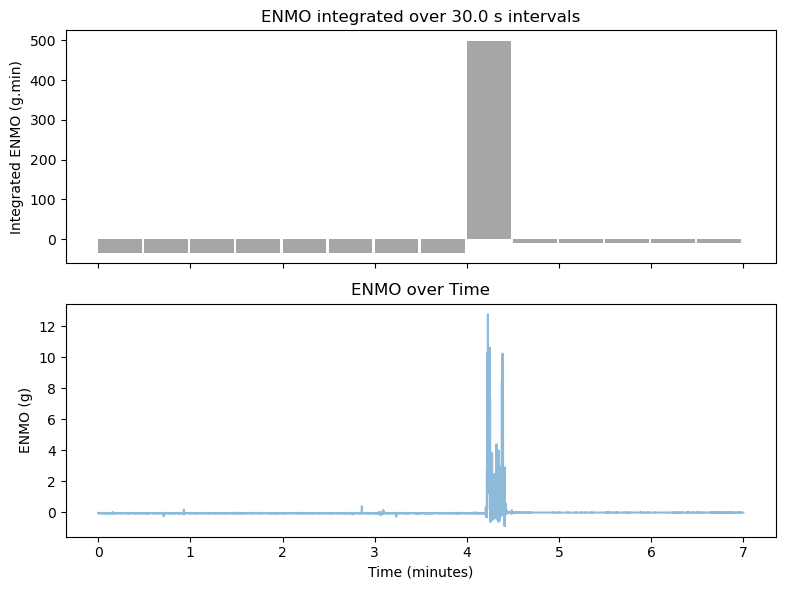

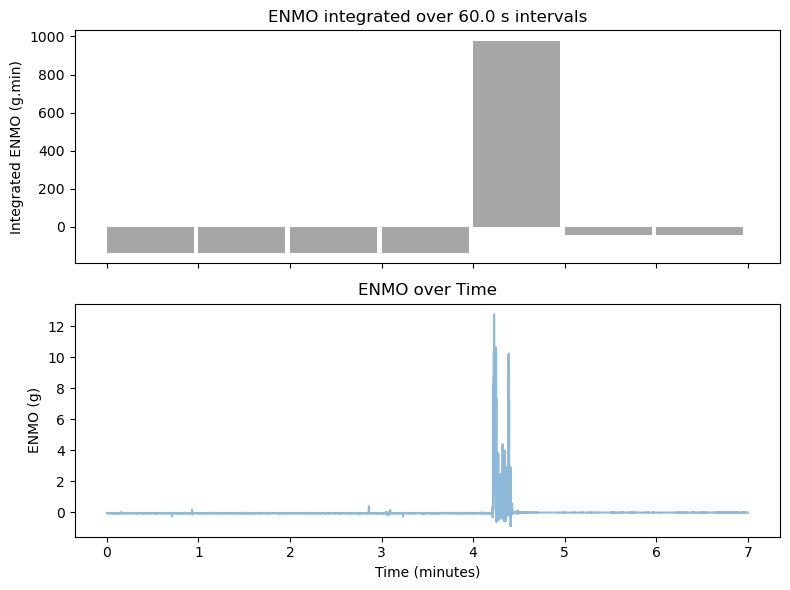

In [8]:
import matplotlib.pyplot as plt

def tracer_enmo(df, resultat_epoque, n_secondes, enmo_colonne="enmo"):
    """Deux panneaux : ENMO intégré par époque (barres) et ENMO brut en fonction du temps (min)."""
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

    # Panneau 1 : barres placées au début de chaque époque (en minutes)
    ax1.bar(resultat_epoque["debut_min"], resultat_epoque["ENMO_g_min"],
            width=n_secondes / 60 * 0.95, align="edge", color="gray", alpha=0.7)
    ax1.set_title(f"ENMO integrated over {n_secondes:.1f} s intervals")
    ax1.set_ylabel("Integrated ENMO (g.min)")

    # Panneau 2 : ENMO brut en fonction du temps en minutes
    ax2.plot(df["t"] / 60, df[enmo_colonne], alpha=0.5)
    ax2.set_title("ENMO over Time")
    ax2.set_xlabel("Time (minutes)")
    ax2.set_ylabel("ENMO (g)")

    plt.tight_layout()
    return fig

fs = 1 / df["t"].diff().median()   # ≈ 50 Hz

for n in (10, 30, 60):
    resultat = enmo_par_epoque(df, n_secondes=n, frequence_hz=fs)
    fig = tracer_enmo(df, resultat, n_secondes=n)
    plt.show()